# Part II — Vision Tasks: Image Classification with CNNs
**Module 6CS012 — Final Portfolio Project**

This notebook implements the Vision Task component of the assessment.

**Dataset:** Traffic Sign images, 4 classes (Caution, Instructions, No Passing, OverSpeed)

**Structure:**
- §2.5.1 Data Understanding, Analysis, Visualization, Cleaning
- §2.5.2 Baseline CNN (3 conv + 3 FC)
- §2.5.3 Deeper Architecture with Regularization
- §2.5.4 Experimentation and Comparative Analysis
- §2.6   Part B — Transfer Learning (MobileNetV2)

---

## Setup — Mount Drive and Extract Dataset

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
import subprocess
result = subprocess.run(
    ['find', '/content/drive/MyDrive', '-name', 'traffic_sign.zip'],
    capture_output=True, text=True
)
print(result.stdout)
print(result.stderr)

/content/drive/MyDrive/traffic_sign.zip




In [18]:
import zipfile, os

zip_path = '/content/drive/MyDrive/traffic_sign.zip'   # ← update this
extract_to = '/content/data'

os.makedirs(extract_to, exist_ok=True)
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_to)

print("Done. Contents of /content/data:")
print(os.listdir(extract_to))

Done. Contents of /content/data:
['traffic_sign']


 Imports

---

## §2.5.1 Data Understanding, Analysis, Visualization, and Cleaning

This section covers exploratory data analysis (EDA): class distribution, sample visualization, image size statistics, and data cleaning (removal of corrupted files).

In [19]:
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from PIL import Image
import random

random.seed(42)
np.random.seed(42)

Set paths and list classes

In [20]:
TRAIN_DIR = '/content/data/traffic_sign/train'
TEST_DIR  = '/content/data/traffic_sign/Test'

classes = sorted(os.listdir(TRAIN_DIR))
print("Classes:", classes)
print("Number of classes:", len(classes))

Classes: ['Caution', 'Instructions', 'No Passing', 'OverSpeed']
Number of classes: 4


Count images per class

In [21]:
counts = {}
for cls in classes:
    cls_dir = os.path.join(TRAIN_DIR, cls)
    n_files = len(os.listdir(cls_dir))
    counts[cls] = n_files

print(f"{'Class':<15} {'Count':>8}")
print('-' * 25)
for cls, n in counts.items():
    print(f"{cls:<15} {n:>8}")
print('-' * 25)
print(f"{'Total':<15} {sum(counts.values()):>8}")

Class              Count
-------------------------
Caution             2429
Instructions        2848
No Passing          5369
OverSpeed           5249
-------------------------
Total              15895


Bar chart of class distribution

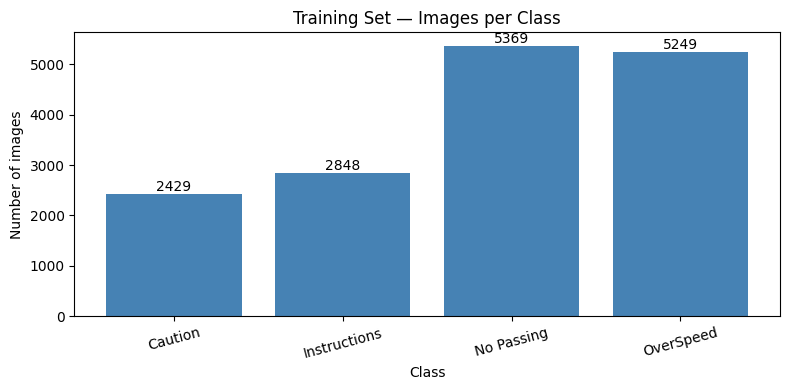

In [22]:
plt.figure(figsize=(8, 4))
plt.bar(counts.keys(), counts.values(), color='steelblue')
plt.title('Training Set — Images per Class')
plt.xlabel('Class')
plt.ylabel('Number of images')
plt.xticks(rotation=15)

# Add the count on top of each bar (nice touch for the report)
for i, (cls, n) in enumerate(counts.items()):
    plt.text(i, n + 50, str(n), ha='center')

plt.tight_layout()
plt.show()

Check the Test folder

In [23]:
test_files = os.listdir(TEST_DIR)
print(f"Test folder contains {len(test_files)} items:")
for f in test_files:
    print(f"  {f}")

# Are these subfolders (labeled) or files (unlabeled)?
first = os.path.join(TEST_DIR, test_files[0])
print(f"\nFirst item is a {'directory' if os.path.isdir(first) else 'file'}")

Test folder contains 4 items:
  00018_00000_00001.png
  00003_00000_00001.png
  00009_00001_00027.png
  00028_00000_00007.png

First item is a file


Find/remove corrupted images

In [24]:
from PIL import Image
import os

bad_files = []
total_checked = 0

for cls in classes:
    cls_dir = os.path.join(TRAIN_DIR, cls)
    for fname in os.listdir(cls_dir):
        fpath = os.path.join(cls_dir, fname)
        total_checked += 1
        try:
            img = Image.open(fpath)
            img.verify()       # checks the file is a valid image
        except Exception as e:
            bad_files.append(fpath)
            print(f"Bad: {fpath} — {type(e).__name__}: {e}")

print(f"\nChecked {total_checked} images")
print(f"Found {len(bad_files)} corrupted/invalid files")

# Delete them
for f in bad_files:
    os.remove(f)
print(f"Deleted {len(bad_files)} files")

Bad: /content/data/traffic_sign/train/Caution/00018_00023_00007.png — UnidentifiedImageError: cannot identify image file '/content/data/traffic_sign/train/Caution/00018_00023_00007.png'
Bad: /content/data/traffic_sign/train/Caution/00022_00001_00001.png — UnidentifiedImageError: cannot identify image file '/content/data/traffic_sign/train/Caution/00022_00001_00001.png'
Bad: /content/data/traffic_sign/train/Caution/00022_00000_00011.png — UnidentifiedImageError: cannot identify image file '/content/data/traffic_sign/train/Caution/00022_00000_00011.png'
Bad: /content/data/traffic_sign/train/Caution/00018_00031_00023.png — UnidentifiedImageError: cannot identify image file '/content/data/traffic_sign/train/Caution/00018_00031_00023.png'
Bad: /content/data/traffic_sign/train/Caution/00018_00031_00016.png — UnidentifiedImageError: cannot identify image file '/content/data/traffic_sign/train/Caution/00018_00031_00016.png'
Bad: /content/data/traffic_sign/train/Caution/00023_00009_00008.png — 

Visualize sample images per class

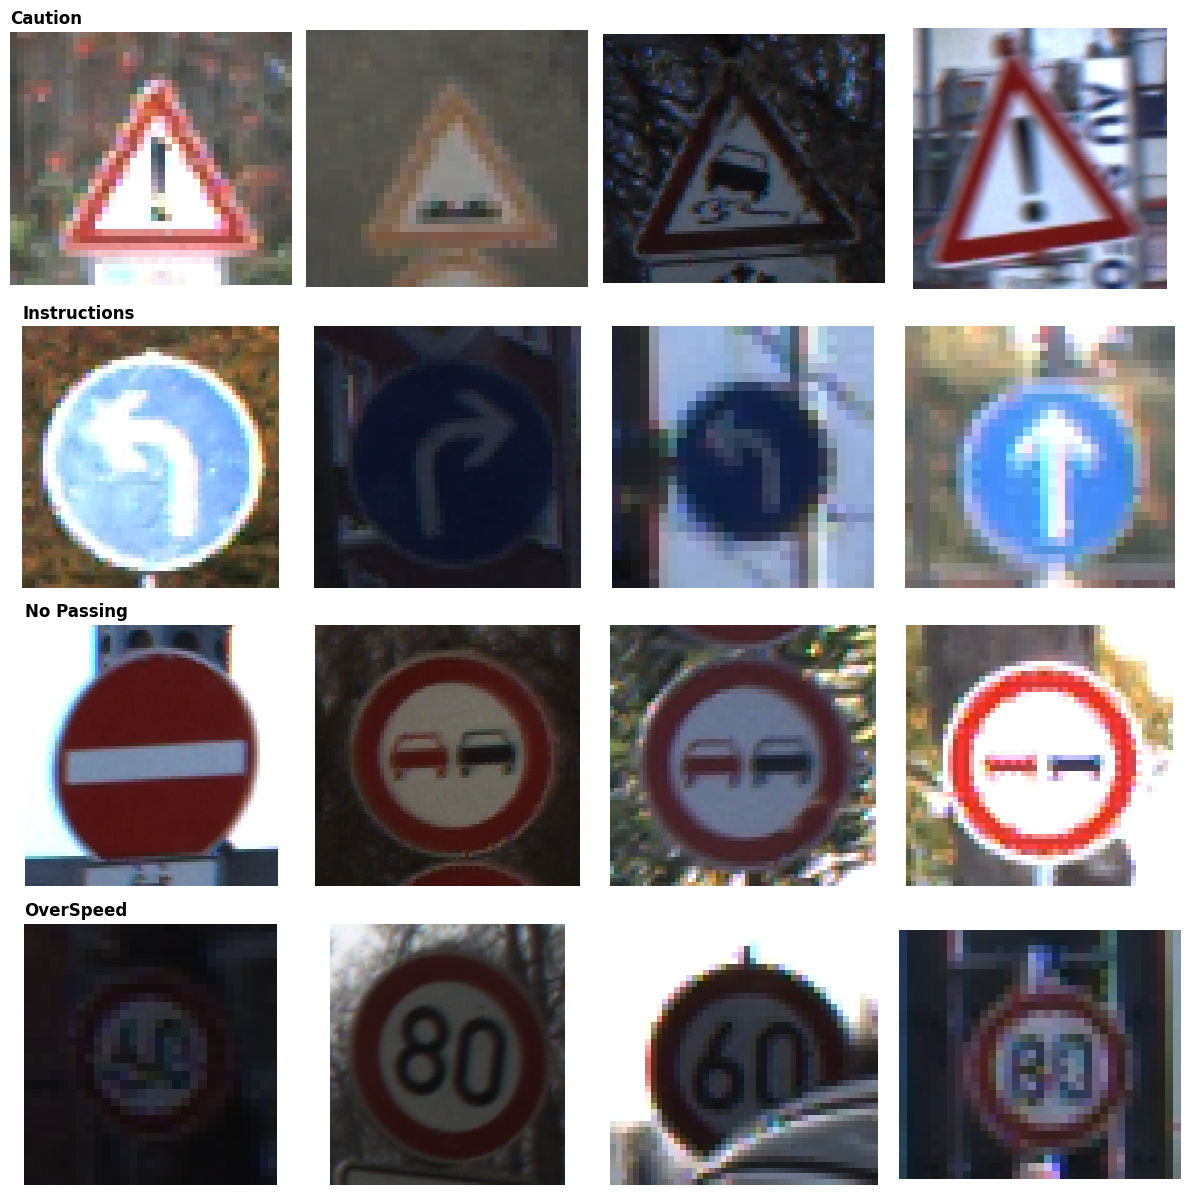

In [25]:
n_samples = 4  # images per class
fig, axes = plt.subplots(len(classes), n_samples, figsize=(12, 12))

for i, cls in enumerate(classes):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    files = os.listdir(cls_dir)
    sample_files = random.sample(files, n_samples)

    for j, f in enumerate(sample_files):
        img = Image.open(os.path.join(cls_dir, f))
        axes[i, j].imshow(img)
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_title(cls, loc='left', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

 Image size distribution

Sampled 400 images
Width  — min: 26, max: 158, mean: 52.2
Height — min: 26, max: 143, mean: 51.6


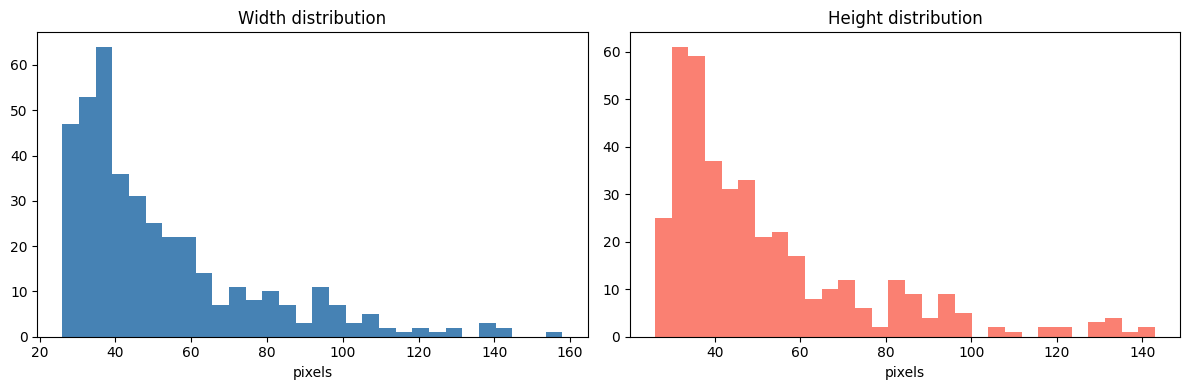

In [26]:
# Sample 100 images from each class and record their dimensions
widths, heights = [], []

for cls in classes:
    cls_dir = os.path.join(TRAIN_DIR, cls)
    files = os.listdir(cls_dir)
    sample = random.sample(files, min(100, len(files)))
    for f in sample:
        img = Image.open(os.path.join(cls_dir, f))
        w, h = img.size
        widths.append(w)
        heights.append(h)

print(f"Sampled {len(widths)} images")
print(f"Width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.1f}")
print(f"Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.1f}")

# Plot histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths, bins=30, color='steelblue')
axes[0].set_title('Width distribution')
axes[0].set_xlabel('pixels')
axes[1].hist(heights, bins=30, color='salmon')
axes[1].set_title('Height distribution')
axes[1].set_xlabel('pixels')
plt.tight_layout()
plt.show()

### Data Generators (Train / Validation Split + Augmentation)

A stratified 80/20 split is used. Augmentation (rotation, shift, zoom, brightness) is applied to training data only — validation data uses rescale only. Horizontal flip is **not** applied because traffic signs have directional meaning.

 Set up data generators (train/val split + augmentation)

In [27]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 64       # resize to 64x64 for from-scratch CNN
BATCH_SIZE = 32

# Training generator: with augmentation + 20% held out for validation
train_datagen = ImageDataGenerator(
    rescale=1./255,            # pixel values 0–255 → 0–1
    rotation_range=10,         # small rotations only
    width_shift_range=0.1,     # shift up to 10% horizontally
    height_shift_range=0.1,    # shift up to 10% vertically
    zoom_range=0.1,            # mild zoom in/out
    brightness_range=[0.8, 1.2], # vary brightness ±20%
    validation_split=0.2,      # reserve 20% for validation
    # NOTE: no horizontal_flip — would change sign meaning
)

# Validation generator: same rescale, NO augmentation, same split
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',  # one-hot labels for 4 classes
    subset='training',
    shuffle=True,
    seed=42,
)

val_generator = val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42,
)

print("\nClass index mapping:", train_generator.class_indices)

Found 12695 images belonging to 4 classes.
Found 3172 images belonging to 4 classes.

Class index mapping: {'Caution': 0, 'Instructions': 1, 'No Passing': 2, 'OverSpeed': 3}


Visualize augmented images

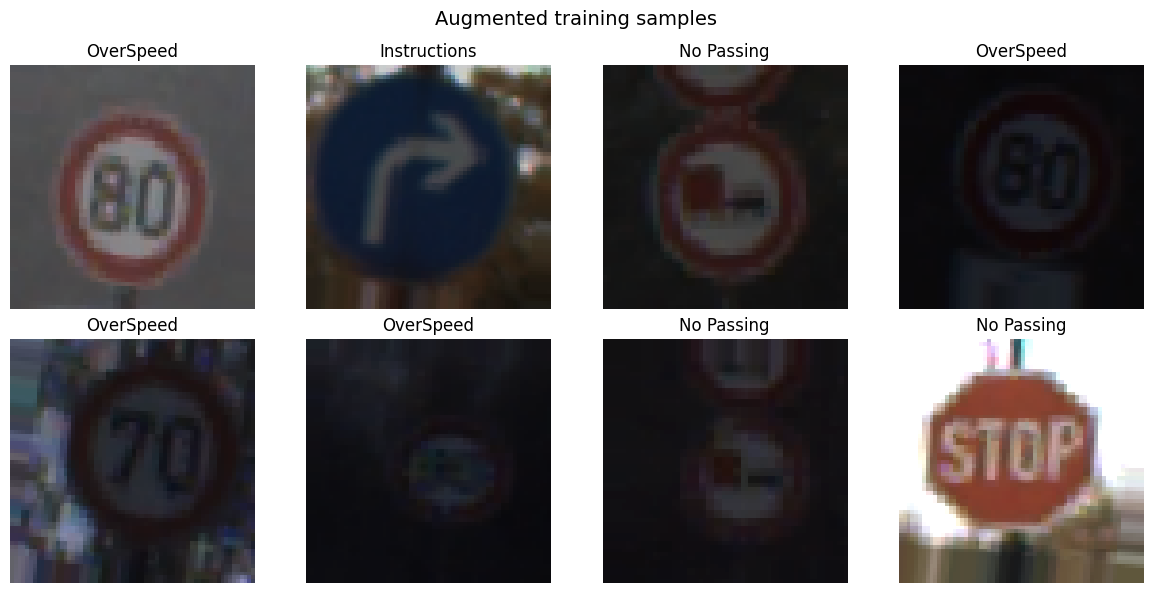

In [28]:
# Grab one batch
images, labels = next(train_generator)
class_names = list(train_generator.class_indices.keys())

# Show 8 augmented images
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i])
    label_idx = np.argmax(labels[i])
    ax.set_title(class_names[label_idx])
    ax.axis('off')
plt.suptitle('Augmented training samples', fontsize=14)
plt.tight_layout()
plt.show()

---

## §2.5.2 Baseline CNN — Design, Train, Evaluate

Baseline architecture as specified by the assignment: 3 convolutional layers (each followed by max-pooling), 3 fully connected layers, and a softmax output for 4 classes.

Build the baseline model

In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input
from tensorflow.keras.optimizers import Adam

# Build the model
baseline_model = Sequential(name='baseline_cnn')

# Input layer — explicitly state input shape
baseline_model.add(Input(shape=(IMG_SIZE, IMG_SIZE, 3)))

# Block 1: 32 filters
baseline_model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'))
baseline_model.add(MaxPooling2D(pool_size=(2, 2)))

# Block 2: 64 filters
baseline_model.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'))
baseline_model.add(MaxPooling2D(pool_size=(2, 2)))

# Block 3: 128 filters
baseline_model.add(Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'))
baseline_model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten 3D feature maps → 1D vector
baseline_model.add(Flatten())

# 3 Fully Connected (Dense) layers
baseline_model.add(Dense(128, activation='relu'))
baseline_model.add(Dense(64, activation='relu'))
baseline_model.add(Dense(4, activation='softmax'))   # 4 classes → softmax

# Compile: tell Keras how to train
baseline_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',   # multi-class, one-hot labels
    metrics=['accuracy']
)

# Print summary — required by assignment §2.5.2
baseline_model.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,150,468 (4.39 MB)

 Trainable params: 1,150,468 (4.39 MB)

 Non-trainable params: 0 (0.00 B)

 Train the baseline model

In [30]:
import tensorflow as tf
print("GPUs available:", tf.config.list_physical_devices('GPU'))

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Train

In [31]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import time

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,                # stop if val_loss doesn't improve for 5 epochs
    restore_best_weights=True  # rewind to the best weights when stopped
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,        # halve learning rate
    patience=3,        # if no improvement for 3 epochs
    min_lr=1e-6,
    verbose=1
)

# Train the model and time it
print("Starting training...")
start = time.time()

baseline_history = baseline_model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

baseline_train_time = time.time() - start
print(f"\nBaseline training time: {baseline_train_time/60:.2f} minutes")

Starting training...
Epoch 1/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 39s 85ms/step - accuracy: 0.9041 - loss: 0.2539 - val_accuracy: 0.7828 - val_loss: 2.6101 - learning_rate: 0.0010
Epoch 2/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 29s 74ms/step - accuracy: 0.9888 - loss: 0.0366 - val_accuracy: 0.8231 - val_loss: 2.6304 - learning_rate: 0.0010
Epoch 3/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 29s 73ms/step - accuracy: 0.9928 - loss: 0.0257 - val_accuracy: 0.7922 - val_loss: 1.7640 - learning_rate: 0.0010
Epoch 4/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 30s 76ms/step - accuracy: 0.9942 - loss: 0.0211 - val_accuracy: 0.8124 - val_loss: 4.7902 - learning_rate: 0.0010
Epoch 5/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 29s 73ms/step - accuracy: 0.9964 - loss: 0.0136 - val_accuracy: 0.8194 - val_loss: 4.8740 - learning_rate: 0.0010
Epoch 6/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9953 - loss: 0.0168
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
397/397 ━━━━━━━━━━━━━━━━━━━━ 29s 73ms/step - a

In [32]:
import tensorflow as tf
print("GPUs available:", tf.config.list_physical_devices('GPU'))
print("Built with CUDA:", tf.test.is_built_with_cuda())

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Built with CUDA: True


Plot training curves

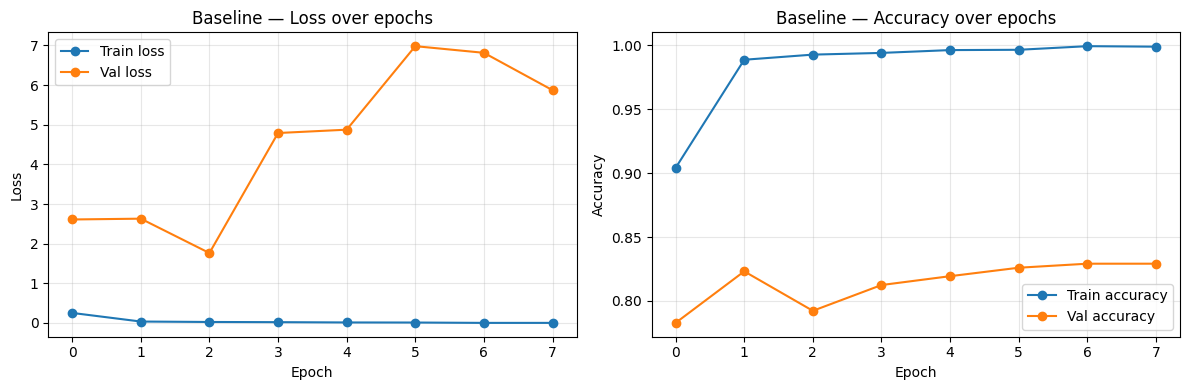

In [33]:
import matplotlib.pyplot as plt

history = baseline_history.history

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(history['loss'], label='Train loss', marker='o')
axes[0].plot(history['val_loss'], label='Val loss', marker='o')
axes[0].set_title('Baseline — Loss over epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history['accuracy'], label='Train accuracy', marker='o')
axes[1].plot(history['val_accuracy'], label='Val accuracy', marker='o')
axes[1].set_title('Baseline — Accuracy over epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Baseline Model — Evaluation

Validation-set evaluation: accuracy, precision, recall, F1-score, classification report, confusion matrix, and inference on sample images.

Compute predictions and metrics

In [34]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
import numpy as np

# Reset validation generator so predictions align with true labels
val_generator.reset()

# Get predictions for the entire validation set
print("Predicting on validation set...")
y_pred_probs = baseline_model.predict(val_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels (in the same order, because shuffle=False)
y_true = val_generator.classes
class_names = list(val_generator.class_indices.keys())

# Compute metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print(f"\n=== Baseline CNN — Validation Metrics ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

# Per-class breakdown
print("\n=== Classification Report (per-class) ===")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

Predicting on validation set...
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step

=== Baseline CNN — Validation Metrics ===
Accuracy : 0.7922
Precision: 0.7658
Recall   : 0.7922
F1-score : 0.7477

=== Classification Report (per-class) ===
              precision    recall  f1-score   support

     Caution       0.46      0.94      0.62       484
Instructions       0.29      0.03      0.06       568
  No Passing       0.99      0.95      0.97      1072
   OverSpeed       0.94      0.97      0.96      1048

    accuracy                           0.79      3172
   macro avg       0.67      0.72      0.65      3172
weighted avg       0.77      0.79      0.75      3172



Confusion matrix

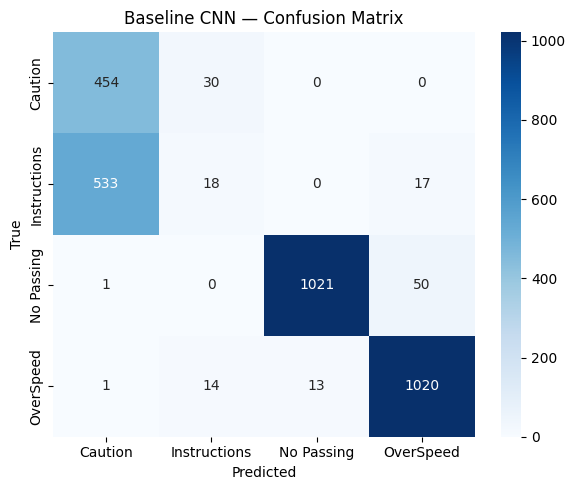

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names
)
plt.title('Baseline CNN — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

 Inference on sample images

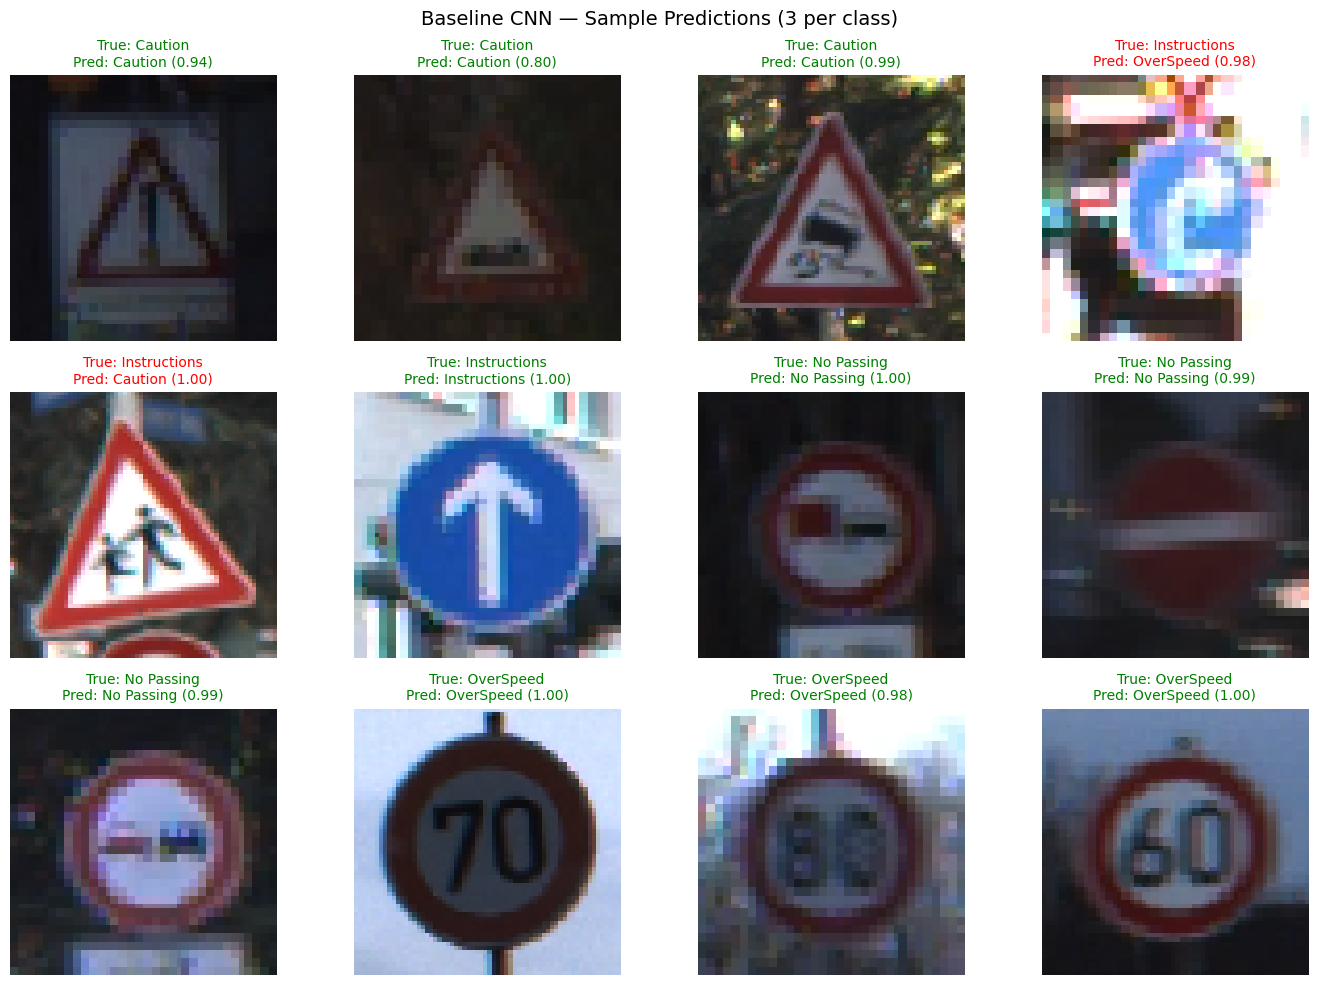

In [37]:
import random

# Build a list of (image_path, true_class_idx) — 2 images from each class
sample_paths = []
for cls_idx, cls in enumerate(class_names):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    files = os.listdir(cls_dir)
    chosen = random.sample(files, 3)  # 3 per class = 12 total
    for f in chosen:
        sample_paths.append((os.path.join(cls_dir, f), cls_idx))

# Load and preprocess
from tensorflow.keras.preprocessing.image import load_img, img_to_array

images = []
true_idxs = []
for path, true_idx in sample_paths:
    img = load_img(path, target_size=(IMG_SIZE, IMG_SIZE))
    arr = img_to_array(img) / 255.0
    images.append(arr)
    true_idxs.append(true_idx)

images = np.array(images)

# Predict
preds = baseline_model.predict(images, verbose=0)

# Plot 3x4 grid
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i])
    true_idx = true_idxs[i]
    pred_idx = np.argmax(preds[i])
    confidence = preds[i][pred_idx]
    color = 'green' if true_idx == pred_idx else 'red'
    title = f"True: {class_names[true_idx]}\nPred: {class_names[pred_idx]} ({confidence:.2f})"
    ax.set_title(title, color=color, fontsize=10)
    ax.axis('off')

plt.suptitle('Baseline CNN — Sample Predictions (3 per class)', fontsize=14)
plt.tight_layout()
plt.show()

---

## §2.5.3 Deeper Architecture with Regularization

Architecture is approximately doubled in depth (6 conv layers vs. baseline's 3) with BatchNormalization and Dropout for regularization. Trained first with Adam (lr=0.001).

Build the deeper model

In [38]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    BatchNormalization, Dropout, Activation, Input
)
from tensorflow.keras.optimizers import Adam

deep_model = Sequential(name='deeper_cnn')

deep_model.add(Input(shape=(IMG_SIZE, IMG_SIZE, 3)))

# --- Stage 1: 32 filters ---
deep_model.add(Conv2D(32, (3, 3), padding='same'))
deep_model.add(BatchNormalization())
deep_model.add(Activation('relu'))

deep_model.add(Conv2D(32, (3, 3), padding='same'))
deep_model.add(BatchNormalization())
deep_model.add(Activation('relu'))

deep_model.add(MaxPooling2D((2, 2)))
deep_model.add(Dropout(0.25))

# --- Stage 2: 64 filters ---
deep_model.add(Conv2D(64, (3, 3), padding='same'))
deep_model.add(BatchNormalization())
deep_model.add(Activation('relu'))

deep_model.add(Conv2D(64, (3, 3), padding='same'))
deep_model.add(BatchNormalization())
deep_model.add(Activation('relu'))

deep_model.add(MaxPooling2D((2, 2)))
deep_model.add(Dropout(0.25))

# --- Stage 3: 128 filters ---
deep_model.add(Conv2D(128, (3, 3), padding='same'))
deep_model.add(BatchNormalization())
deep_model.add(Activation('relu'))

deep_model.add(Conv2D(128, (3, 3), padding='same'))
deep_model.add(BatchNormalization())
deep_model.add(Activation('relu'))

deep_model.add(MaxPooling2D((2, 2)))
deep_model.add(Dropout(0.25))

# --- Fully connected layers ---
deep_model.add(Flatten())

deep_model.add(Dense(256))
deep_model.add(BatchNormalization())
deep_model.add(Activation('relu'))
deep_model.add(Dropout(0.5))

deep_model.add(Dense(128))
deep_model.add(BatchNormalization())
deep_model.add(Activation('relu'))
deep_model.add(Dropout(0.5))

deep_model.add(Dense(4, activation='softmax'))

# Compile with Adam first
deep_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

deep_model.summary()

Model: "deeper_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 16, 16, 128)    │             

 Total params: 2,421,156 (9.24 MB)

 Trainable params: 2,419,492 (9.23 MB)

 Non-trainable params: 1,664 (6.50 KB)

 Train the deeper model with Adam

In [39]:
import time

# Fresh callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

print("Training deeper model with Adam...")
start = time.time()

deep_history_adam = deep_model.fit(
    train_generator,
    epochs=25,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

deep_train_time_adam = time.time() - start
print(f"\nDeeper (Adam) training time: {deep_train_time_adam/60:.2f} minutes")

Training deeper model with Adam...
Epoch 1/25
397/397 ━━━━━━━━━━━━━━━━━━━━ 60s 113ms/step - accuracy: 0.8476 - loss: 0.4017 - val_accuracy: 0.6709 - val_loss: 1.6834 - learning_rate: 0.0010
Epoch 2/25
397/397 ━━━━━━━━━━━━━━━━━━━━ 31s 79ms/step - accuracy: 0.9779 - loss: 0.0749 - val_accuracy: 0.8184 - val_loss: 1.7939 - learning_rate: 0.0010
Epoch 3/25
397/397 ━━━━━━━━━━━━━━━━━━━━ 33s 83ms/step - accuracy: 0.9865 - loss: 0.0449 - val_accuracy: 0.8285 - val_loss: 2.2839 - learning_rate: 0.0010
Epoch 4/25
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.9912 - loss: 0.0308
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
397/397 ━━━━━━━━━━━━━━━━━━━━ 31s 79ms/step - accuracy: 0.9912 - loss: 0.0313 - val_accuracy: 0.8291 - val_loss: 2.0918 - learning_rate: 0.0010
Epoch 5/25
397/397 ━━━━━━━━━━━━━━━━━━━━ 32s 80ms/step - accuracy: 0.9943 - loss: 0.0202 - val_accuracy: 0.8272 - val_loss: 2.2072 - learning_rate: 5.0000e-04
Epoch 6/25
397/397 ━━━━━━━━━━━━━━━━━━━

Plot deeper model curves

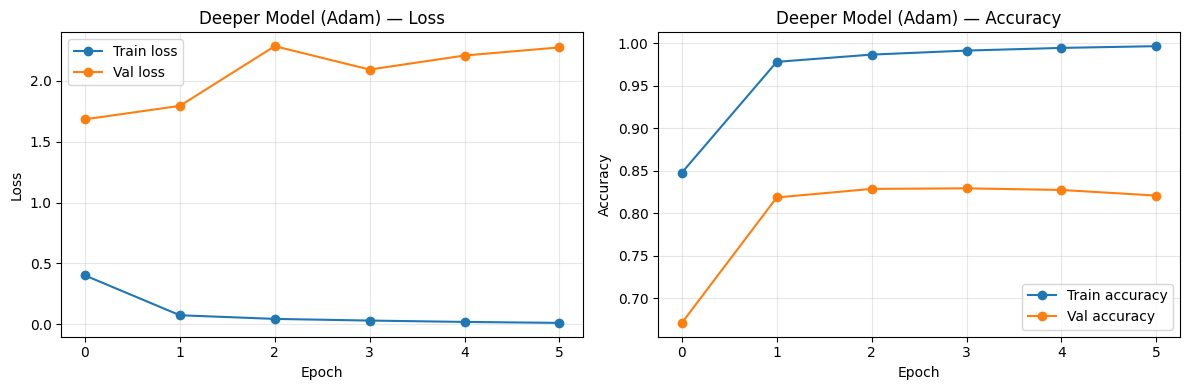

In [40]:
import matplotlib.pyplot as plt

history = deep_history_adam.history

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['loss'], label='Train loss', marker='o')
axes[0].plot(history['val_loss'], label='Val loss', marker='o')
axes[0].set_title('Deeper Model (Adam) — Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['accuracy'], label='Train accuracy', marker='o')
axes[1].plot(history['val_accuracy'], label='Val accuracy', marker='o')
axes[1].set_title('Deeper Model (Adam) — Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Evaluate the deeper model (per-class metrics)

Predicting on validation set...


100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step

=== Deeper Model (Adam) — Validation Metrics ===
Accuracy : 0.6709
Precision: 0.8154
Recall   : 0.6709
F1-score : 0.6393

=== Classification Report (per-class) ===
              precision    recall  f1-score   support

     Caution       0.37      0.85      0.52       484
Instructions       1.00      0.05      0.10       568
  No Passing       1.00      0.68      0.81      1072
   OverSpeed       0.73      0.91      0.81      1048

    accuracy                           0.67      3172
   macro avg       0.78      0.62      0.56      3172
weighted avg       0.82      0.67      0.64      3172



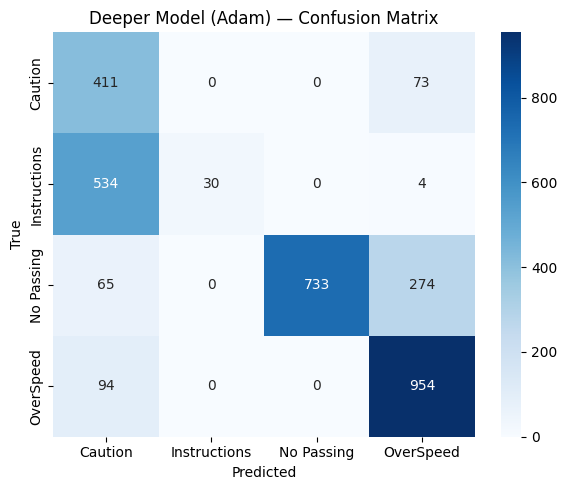

In [41]:
val_generator.reset()
print("Predicting on validation set...")
y_pred_probs_deep = deep_model.predict(val_generator, verbose=1)
y_pred_deep = np.argmax(y_pred_probs_deep, axis=1)

y_true = val_generator.classes  # same as before

acc_d  = accuracy_score(y_true, y_pred_deep)
prec_d = precision_score(y_true, y_pred_deep, average='weighted', zero_division=0)
rec_d  = recall_score(y_true, y_pred_deep, average='weighted', zero_division=0)
f1_d   = f1_score(y_true, y_pred_deep, average='weighted', zero_division=0)

print(f"\n=== Deeper Model (Adam) — Validation Metrics ===")
print(f"Accuracy : {acc_d:.4f}")
print(f"Precision: {prec_d:.4f}")
print(f"Recall   : {rec_d:.4f}")
print(f"F1-score : {f1_d:.4f}")

print("\n=== Classification Report (per-class) ===")
print(classification_report(y_true, y_pred_deep, target_names=class_names, zero_division=0))

# Confusion matrix
cm_d = confusion_matrix(y_true, y_pred_deep)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_d, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Deeper Model (Adam) — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

---

## §2.5.4 Experimentation and Comparative Analysis

### Experiment: Adam (lr=0.0003) + Class Weights — *Failed configuration, retained for documentation*

This configuration was attempted to address class imbalance using `class_weight`. However, the unweighted validation accuracy was only ~0.55, with predictions collapsing toward OverSpeed. The displayed `val_accuracy` during training (~0.83) was a weighted metric due to the `class_weight` parameter, masking the actual underperformance. A diagnostic cell below confirms this. We retain this experiment as part of the experimental record but use the original Adam-trained deeper model and the SGD-trained version (below) as the reference deeper models in the comparative analysis.

Build a fresh deeper model

In [42]:
# Rebuild the deeper model from scratch (fresh weights)
deep_model_v2 = Sequential(name='deeper_cnn_v2')

deep_model_v2.add(Input(shape=(IMG_SIZE, IMG_SIZE, 3)))

# Stage 1
deep_model_v2.add(Conv2D(32, (3, 3), padding='same'))
deep_model_v2.add(BatchNormalization())
deep_model_v2.add(Activation('relu'))
deep_model_v2.add(Conv2D(32, (3, 3), padding='same'))
deep_model_v2.add(BatchNormalization())
deep_model_v2.add(Activation('relu'))
deep_model_v2.add(MaxPooling2D((2, 2)))
deep_model_v2.add(Dropout(0.25))

# Stage 2
deep_model_v2.add(Conv2D(64, (3, 3), padding='same'))
deep_model_v2.add(BatchNormalization())
deep_model_v2.add(Activation('relu'))
deep_model_v2.add(Conv2D(64, (3, 3), padding='same'))
deep_model_v2.add(BatchNormalization())
deep_model_v2.add(Activation('relu'))
deep_model_v2.add(MaxPooling2D((2, 2)))
deep_model_v2.add(Dropout(0.25))

# Stage 3
deep_model_v2.add(Conv2D(128, (3, 3), padding='same'))
deep_model_v2.add(BatchNormalization())
deep_model_v2.add(Activation('relu'))
deep_model_v2.add(Conv2D(128, (3, 3), padding='same'))
deep_model_v2.add(BatchNormalization())
deep_model_v2.add(Activation('relu'))
deep_model_v2.add(MaxPooling2D((2, 2)))
deep_model_v2.add(Dropout(0.25))

# Dense
deep_model_v2.add(Flatten())
deep_model_v2.add(Dense(256))
deep_model_v2.add(BatchNormalization())
deep_model_v2.add(Activation('relu'))
deep_model_v2.add(Dropout(0.5))
deep_model_v2.add(Dense(128))
deep_model_v2.add(BatchNormalization())
deep_model_v2.add(Activation('relu'))
deep_model_v2.add(Dropout(0.5))
deep_model_v2.add(Dense(4, activation='softmax'))

# Lower learning rate this time
deep_model_v2.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Built v2 with Adam lr=0.0003")
print(f"Total params: {deep_model_v2.count_params():,}")

Built v2 with Adam lr=0.0003
Total params: 2,421,156


 Compute class weights and train



In [43]:
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights from the training generator's class indices
y_train_classes = train_generator.classes
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_classes),
    y=y_train_classes
)
class_weights_dict = dict(enumerate(class_weights_array))
print("Class weights:", class_weights_dict)

# Fresh callbacks (re-define to be safe)
early_stop_v2 = EarlyStopping(
    monitor='val_loss',
    patience=7,           # a bit more patience since LR is lower
    restore_best_weights=True
)

reduce_lr_v2 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

import time
print("\nTraining deeper v2 (lower LR + class weights)...")
start = time.time()

deep_history_v2 = deep_model_v2.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[early_stop_v2, reduce_lr_v2],
    class_weight=class_weights_dict,    # ← the key change
    verbose=1
)

deep_train_time_v2 = time.time() - start
print(f"\nDeeper v2 training time: {deep_train_time_v2/60:.2f} minutes")

Class weights: {0: np.float64(1.6376418988648092), 1: np.float64(1.3962824461064671), 2: np.float64(0.7398018648018648), 3: np.float64(0.7567358130662851)}

Training deeper v2 (lower LR + class weights)...
Epoch 1/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 63s 122ms/step - accuracy: 0.7528 - loss: 0.5803 - val_accuracy: 0.5476 - val_loss: 1.3591 - learning_rate: 3.0000e-04
Epoch 2/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 30s 75ms/step - accuracy: 0.9516 - loss: 0.1441 - val_accuracy: 0.7992 - val_loss: 2.0245 - learning_rate: 3.0000e-04
Epoch 3/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 31s 77ms/step - accuracy: 0.9778 - loss: 0.0709 - val_accuracy: 0.8061 - val_loss: 2.0388 - learning_rate: 3.0000e-04
Epoch 4/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9864 - loss: 0.0488
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
397/397 ━━━━━━━━━━━━━━━━━━━━ 31s 77ms/step - accuracy: 0.9863 - loss: 0.0458 - val_accuracy: 0.8181 - val_loss: 2.0003 - learning_rate: 3.0000e-04
Epoch 5/3

Predicting on validation set with v2...
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step

=== Deeper v2 (Adam lr=0.0003 + class weights) — Validation Metrics ===
Accuracy : 0.5476
Precision: 0.7428
Recall   : 0.5476
F1-score : 0.4845

=== Classification Report (per-class) ===
              precision    recall  f1-score   support

     Caution       0.40      0.53      0.45       484
Instructions       1.00      0.00      0.00       568
  No Passing       1.00      0.40      0.58      1072
   OverSpeed       0.50      1.00      0.67      1048

    accuracy                           0.55      3172
   macro avg       0.72      0.48      0.42      3172
weighted avg       0.74      0.55      0.48      3172



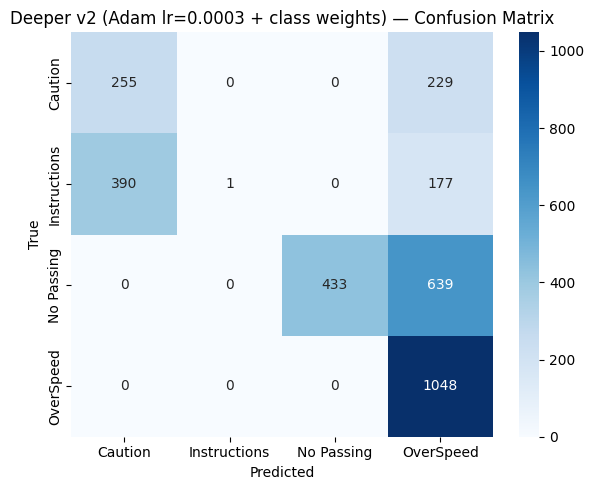

In [44]:
val_generator.reset()
print("Predicting on validation set with v2...")
y_pred_probs_v2 = deep_model_v2.predict(val_generator, verbose=1)
y_pred_v2 = np.argmax(y_pred_probs_v2, axis=1)

y_true = val_generator.classes

acc_v2  = accuracy_score(y_true, y_pred_v2)
prec_v2 = precision_score(y_true, y_pred_v2, average='weighted', zero_division=0)
rec_v2  = recall_score(y_true, y_pred_v2, average='weighted', zero_division=0)
f1_v2   = f1_score(y_true, y_pred_v2, average='weighted', zero_division=0)

print(f"\n=== Deeper v2 (Adam lr=0.0003 + class weights) — Validation Metrics ===")
print(f"Accuracy : {acc_v2:.4f}")
print(f"Precision: {prec_v2:.4f}")
print(f"Recall   : {rec_v2:.4f}")
print(f"F1-score : {f1_v2:.4f}")

print("\n=== Classification Report (per-class) ===")
print(classification_report(y_true, y_pred_v2, target_names=class_names, zero_division=0))

# Confusion matrix
cm_v2 = confusion_matrix(y_true, y_pred_v2)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_v2, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Deeper v2 (Adam lr=0.0003 + class weights) — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

Found 3172 images belonging to 4 classes.
Re-evaluating with model.evaluate()...
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.5476 - loss: 1.3591

Keras evaluate: loss=1.3591, accuracy=0.5476

Manual evaluation: accuracy = 0.5476

Classification report (correctly aligned):
              precision    recall  f1-score   support

     Caution       0.40      0.53      0.45       484
Instructions       1.00      0.00      0.00       568
  No Passing       1.00      0.40      0.58      1072
   OverSpeed       0.50      1.00      0.67      1048

    accuracy                           0.55      3172
   macro avg       0.72      0.48      0.42      3172
weighted avg       0.74      0.55      0.48      3172



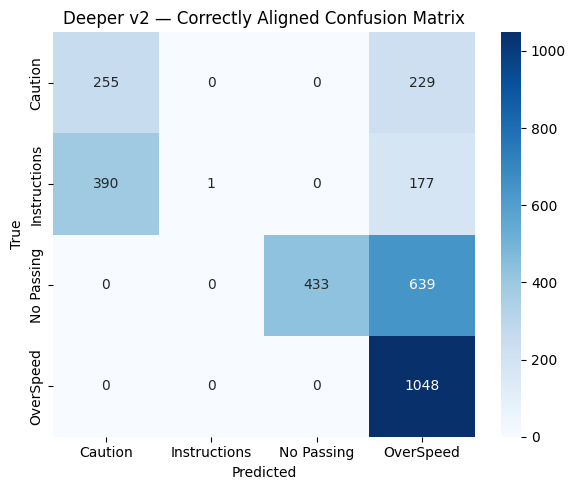

In [45]:
# Diagnostic: re-create a fresh val generator that returns labels with predictions
val_datagen_diag = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
)

val_gen_diag = val_datagen_diag.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42,
)

# Use evaluate() — Keras handles label alignment internally
print("Re-evaluating with model.evaluate()...")
loss, acc = deep_model_v2.evaluate(val_gen_diag, verbose=1)
print(f"\nKeras evaluate: loss={loss:.4f}, accuracy={acc:.4f}")

# Now predictions, paired correctly using the same fresh generator
val_gen_diag.reset()

# Collect labels and predictions in lockstep
all_y_true = []
all_y_pred = []
n_batches = len(val_gen_diag)
for i in range(n_batches):
    x_batch, y_batch = val_gen_diag[i]
    p_batch = deep_model_v2.predict(x_batch, verbose=0)
    all_y_true.extend(np.argmax(y_batch, axis=1))
    all_y_pred.extend(np.argmax(p_batch, axis=1))

all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)

print(f"\nManual evaluation: accuracy = {accuracy_score(all_y_true, all_y_pred):.4f}")
print("\nClassification report (correctly aligned):")
print(classification_report(all_y_true, all_y_pred, target_names=class_names, zero_division=0))

# Confusion matrix
cm_correct = confusion_matrix(all_y_true, all_y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_correct, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Deeper v2 — Correctly Aligned Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

### Optimizer Comparison: SGD vs. Adam

Same deeper architecture, retrained with SGD + momentum (lr=0.01, momentum=0.9). Per assignment §2.5.4, this allows direct comparison of optimizer effects on convergence speed and final performance.

Build a fresh deeper model and train with SGD

In [46]:
from tensorflow.keras.optimizers import SGD

# Build a fresh copy with the SAME architecture as v1
deep_model_sgd = Sequential(name='deeper_cnn_sgd')

deep_model_sgd.add(Input(shape=(IMG_SIZE, IMG_SIZE, 3)))

# Stage 1
deep_model_sgd.add(Conv2D(32, (3, 3), padding='same'))
deep_model_sgd.add(BatchNormalization())
deep_model_sgd.add(Activation('relu'))
deep_model_sgd.add(Conv2D(32, (3, 3), padding='same'))
deep_model_sgd.add(BatchNormalization())
deep_model_sgd.add(Activation('relu'))
deep_model_sgd.add(MaxPooling2D((2, 2)))
deep_model_sgd.add(Dropout(0.25))

# Stage 2
deep_model_sgd.add(Conv2D(64, (3, 3), padding='same'))
deep_model_sgd.add(BatchNormalization())
deep_model_sgd.add(Activation('relu'))
deep_model_sgd.add(Conv2D(64, (3, 3), padding='same'))
deep_model_sgd.add(BatchNormalization())
deep_model_sgd.add(Activation('relu'))
deep_model_sgd.add(MaxPooling2D((2, 2)))
deep_model_sgd.add(Dropout(0.25))

# Stage 3
deep_model_sgd.add(Conv2D(128, (3, 3), padding='same'))
deep_model_sgd.add(BatchNormalization())
deep_model_sgd.add(Activation('relu'))
deep_model_sgd.add(Conv2D(128, (3, 3), padding='same'))
deep_model_sgd.add(BatchNormalization())
deep_model_sgd.add(Activation('relu'))
deep_model_sgd.add(MaxPooling2D((2, 2)))
deep_model_sgd.add(Dropout(0.25))

# Dense
deep_model_sgd.add(Flatten())
deep_model_sgd.add(Dense(256))
deep_model_sgd.add(BatchNormalization())
deep_model_sgd.add(Activation('relu'))
deep_model_sgd.add(Dropout(0.5))
deep_model_sgd.add(Dense(128))
deep_model_sgd.add(BatchNormalization())
deep_model_sgd.add(Activation('relu'))
deep_model_sgd.add(Dropout(0.5))
deep_model_sgd.add(Dense(4, activation='softmax'))

# Compile with SGD + momentum (NO class weights this time)
deep_model_sgd.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Built deeper_cnn_sgd with SGD optimizer")
print(f"Total params: {deep_model_sgd.count_params():,}")

Built deeper_cnn_sgd with SGD optimizer
Total params: 2,421,156


Train with SGD

In [47]:
# Fresh callbacks
early_stop_sgd = EarlyStopping(
    monitor='val_loss',
    patience=7,            # more patience because SGD converges slower
    restore_best_weights=True
)

reduce_lr_sgd = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

import time
print("Training deeper model with SGD...")
start = time.time()

deep_history_sgd = deep_model_sgd.fit(
    train_generator,
    epochs=30,             # SGD needs more epochs typically
    validation_data=val_generator,
    callbacks=[early_stop_sgd, reduce_lr_sgd],
    verbose=1
)

deep_train_time_sgd = time.time() - start
print(f"\nDeeper (SGD) training time: {deep_train_time_sgd/60:.2f} minutes")

Training deeper model with SGD...
Epoch 1/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 52s 105ms/step - accuracy: 0.7416 - loss: 0.6068 - val_accuracy: 0.7916 - val_loss: 1.2930 - learning_rate: 0.0100
Epoch 2/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 30s 75ms/step - accuracy: 0.9588 - loss: 0.1296 - val_accuracy: 0.8112 - val_loss: 1.7166 - learning_rate: 0.0100
Epoch 3/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 30s 75ms/step - accuracy: 0.9789 - loss: 0.0657 - val_accuracy: 0.8194 - val_loss: 2.1057 - learning_rate: 0.0100
Epoch 4/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9839 - loss: 0.0597
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.
397/397 ━━━━━━━━━━━━━━━━━━━━ 31s 77ms/step - accuracy: 0.9853 - loss: 0.0486 - val_accuracy: 0.8291 - val_loss: 2.0973 - learning_rate: 0.0100
Epoch 5/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 31s 78ms/step - accuracy: 0.9902 - loss: 0.0318 - val_accuracy: 0.8228 - val_loss: 2.2370 - learning_rate: 0.0050
Epoch 6/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 30s 

evaluate SGD properly

Found 3172 images belonging to 4 classes.
Evaluating deep_model_sgd...
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.7916 - loss: 1.2930

SGD model — Keras evaluate: loss=1.2930, accuracy=0.7916

=== Deeper Model (SGD) — Classification Report ===
              precision    recall  f1-score   support

     Caution       0.45      1.00      0.62       484
Instructions       1.00      0.04      0.08       568
  No Passing       1.00      0.92      0.96      1072
   OverSpeed       0.93      0.97      0.95      1048

    accuracy                           0.79      3172
   macro avg       0.85      0.73      0.65      3172
weighted avg       0.89      0.79      0.75      3172



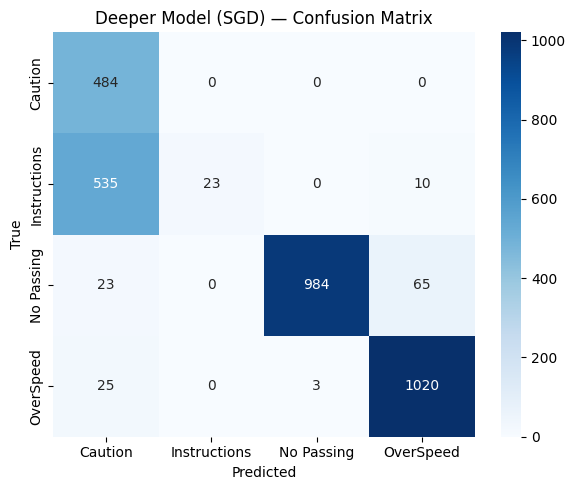

In [48]:


# Evaluate SGD-trained deeper model
val_gen_sgd_eval = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
).flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42,
)

print("Evaluating deep_model_sgd...")
loss_sgd, acc_sgd = deep_model_sgd.evaluate(val_gen_sgd_eval, verbose=1)
print(f"\nSGD model — Keras evaluate: loss={loss_sgd:.4f}, accuracy={acc_sgd:.4f}")

# Manual loop for confusion matrix
val_gen_sgd_eval.reset()
y_true_sgd = []
y_pred_sgd = []
for i in range(len(val_gen_sgd_eval)):
    x_batch, y_batch = val_gen_sgd_eval[i]
    p_batch = deep_model_sgd.predict(x_batch, verbose=0)
    y_true_sgd.extend(np.argmax(y_batch, axis=1))
    y_pred_sgd.extend(np.argmax(p_batch, axis=1))

y_true_sgd = np.array(y_true_sgd)
y_pred_sgd = np.array(y_pred_sgd)

print("\n=== Deeper Model (SGD) — Classification Report ===")
print(classification_report(y_true_sgd, y_pred_sgd, target_names=class_names, zero_division=0))

# Confusion matrix
cm_sgd = confusion_matrix(y_true_sgd, y_pred_sgd)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_sgd, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Deeper Model (SGD) — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()


plotting the SGD training curves

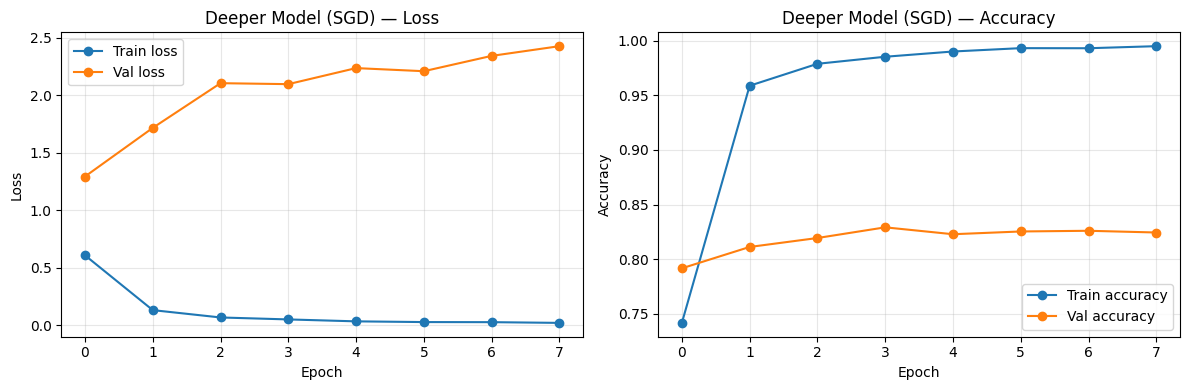

In [49]:
history_sgd = deep_history_sgd.history

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_sgd['loss'], label='Train loss', marker='o')
axes[0].plot(history_sgd['val_loss'], label='Val loss', marker='o')
axes[0].set_title('Deeper Model (SGD) — Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_sgd['accuracy'], label='Train accuracy', marker='o')
axes[1].plot(history_sgd['val_accuracy'], label='Val accuracy', marker='o')
axes[1].set_title('Deeper Model (SGD) — Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Ablation Study — Removing Dropout

Per assignment §2.5.4, one regularization component is removed to measure its contribution. We remove **Dropout** while retaining BatchNormalization, using SGD (the better-performing optimizer).

 no-Dropout version

In [50]:
# Build deeper CNN WITHOUT Dropout (BatchNorm kept)
deep_model_nodrop = Sequential(name='deeper_cnn_no_dropout')

deep_model_nodrop.add(Input(shape=(IMG_SIZE, IMG_SIZE, 3)))

# Stage 1
deep_model_nodrop.add(Conv2D(32, (3, 3), padding='same'))
deep_model_nodrop.add(BatchNormalization())
deep_model_nodrop.add(Activation('relu'))
deep_model_nodrop.add(Conv2D(32, (3, 3), padding='same'))
deep_model_nodrop.add(BatchNormalization())
deep_model_nodrop.add(Activation('relu'))
deep_model_nodrop.add(MaxPooling2D((2, 2)))
# NO Dropout here

# Stage 2
deep_model_nodrop.add(Conv2D(64, (3, 3), padding='same'))
deep_model_nodrop.add(BatchNormalization())
deep_model_nodrop.add(Activation('relu'))
deep_model_nodrop.add(Conv2D(64, (3, 3), padding='same'))
deep_model_nodrop.add(BatchNormalization())
deep_model_nodrop.add(Activation('relu'))
deep_model_nodrop.add(MaxPooling2D((2, 2)))
# NO Dropout here

# Stage 3
deep_model_nodrop.add(Conv2D(128, (3, 3), padding='same'))
deep_model_nodrop.add(BatchNormalization())
deep_model_nodrop.add(Activation('relu'))
deep_model_nodrop.add(Conv2D(128, (3, 3), padding='same'))
deep_model_nodrop.add(BatchNormalization())
deep_model_nodrop.add(Activation('relu'))
deep_model_nodrop.add(MaxPooling2D((2, 2)))
# NO Dropout here

# Dense
deep_model_nodrop.add(Flatten())
deep_model_nodrop.add(Dense(256))
deep_model_nodrop.add(BatchNormalization())
deep_model_nodrop.add(Activation('relu'))
# NO Dropout here
deep_model_nodrop.add(Dense(128))
deep_model_nodrop.add(BatchNormalization())
deep_model_nodrop.add(Activation('relu'))
# NO Dropout here
deep_model_nodrop.add(Dense(4, activation='softmax'))

# Same SGD setup as the winning configuration
deep_model_nodrop.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Built deeper CNN without Dropout")
print(f"Total params: {deep_model_nodrop.count_params():,}")

Built deeper CNN without Dropout
Total params: 2,421,156


 Train

In [51]:
early_stop_abl = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

reduce_lr_abl = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

import time
print("Training deeper model WITHOUT Dropout (ablation)...")
start = time.time()

deep_history_nodrop = deep_model_nodrop.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[early_stop_abl, reduce_lr_abl],
    verbose=1
)

deep_train_time_nodrop = time.time() - start
print(f"\nAblation (no Dropout) training time: {deep_train_time_nodrop/60:.2f} minutes")

Training deeper model WITHOUT Dropout (ablation)...
Epoch 1/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 55s 110ms/step - accuracy: 0.9252 - loss: 0.1989 - val_accuracy: 0.7919 - val_loss: 1.9658 - learning_rate: 0.0100
Epoch 2/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 31s 78ms/step - accuracy: 0.9914 - loss: 0.0276 - val_accuracy: 0.7194 - val_loss: 2.0398 - learning_rate: 0.0100
Epoch 3/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 30s 76ms/step - accuracy: 0.9942 - loss: 0.0177 - val_accuracy: 0.8083 - val_loss: 1.9343 - learning_rate: 0.0100
Epoch 4/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 30s 77ms/step - accuracy: 0.9961 - loss: 0.0140 - val_accuracy: 0.8247 - val_loss: 1.8889 - learning_rate: 0.0100
Epoch 5/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 30s 76ms/step - accuracy: 0.9972 - loss: 0.0101 - val_accuracy: 0.7834 - val_loss: 1.7914 - learning_rate: 0.0100
Epoch 6/20
397/397 ━━━━━━━━━━━━━━━━━━━━ 32s 80ms/step - accuracy: 0.9976 - loss: 0.0088 - val_accuracy: 0.8168 - val_loss: 1.7696 - learning_rate: 0.0100
Epoch 7/20
397/397 ━━━━

 Evaluate it (alignment-safe)

In [52]:
val_gen_abl = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
).flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42,
)

print("Evaluating ablation model...")
loss_abl, acc_abl = deep_model_nodrop.evaluate(val_gen_abl, verbose=1)
print(f"\nAblation (no Dropout) — Val accuracy: {acc_abl:.4f}, Val loss: {loss_abl:.4f}")

# Manual loop for confusion matrix
val_gen_abl.reset()
y_true_abl, y_pred_abl = [], []
for i in range(len(val_gen_abl)):
    x, y = val_gen_abl[i]
    p = deep_model_nodrop.predict(x, verbose=0)
    y_true_abl.extend(np.argmax(y, axis=1))
    y_pred_abl.extend(np.argmax(p, axis=1))

print("\n=== Ablation (no Dropout) — Per-class metrics ===")
print(classification_report(y_true_abl, y_pred_abl, target_names=class_names, zero_division=0))

Found 3172 images belonging to 4 classes.
Evaluating ablation model...
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.8168 - loss: 1.7696

Ablation (no Dropout) — Val accuracy: 0.8168, Val loss: 1.7696

=== Ablation (no Dropout) — Per-class metrics ===
              precision    recall  f1-score   support

     Caution       0.47      1.00      0.64       484
Instructions       0.92      0.06      0.11       568
  No Passing       1.00      0.96      0.98      1072
   OverSpeed       0.96      1.00      0.98      1048

    accuracy                           0.82      3172
   macro avg       0.84      0.75      0.68      3172
weighted avg       0.89      0.82      0.77      3172



Plot ablation curves

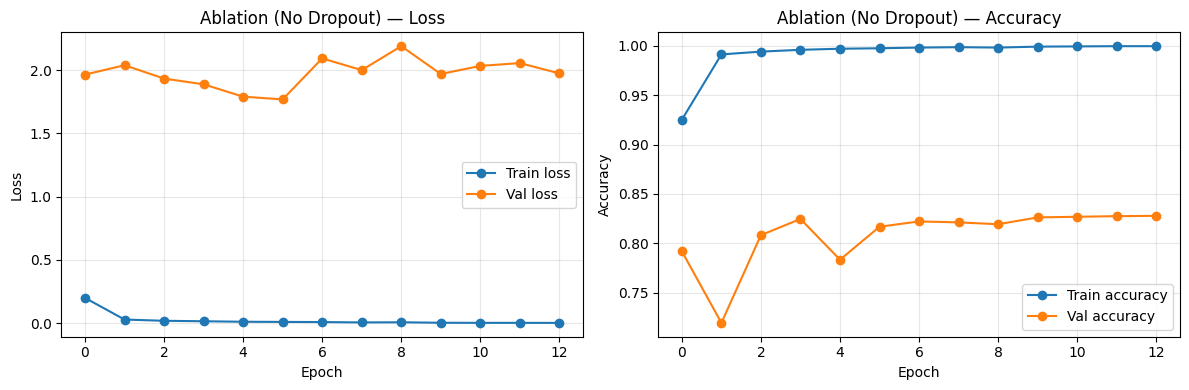

In [53]:
history_abl = deep_history_nodrop.history

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_abl['loss'], label='Train loss', marker='o')
axes[0].plot(history_abl['val_loss'], label='Val loss', marker='o')
axes[0].set_title('Ablation (No Dropout) — Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_abl['accuracy'], label='Train accuracy', marker='o')
axes[1].plot(history_abl['val_accuracy'], label='Val accuracy', marker='o')
axes[1].set_title('Ablation (No Dropout) — Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## §2.6 Part B — Transfer Learning with MobileNetV2

Pre-trained model (MobileNetV2 with ImageNet weights). The convolutional base is frozen (feature extraction); a new classification head is added with GlobalAveragePooling2D, Dense layers, and Dropout. Three input configurations are evaluated.

### Configuration 1: 96×96 input, with augmentation

 Setup data generators for MobileNet


In [54]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

MOBILENET_IMG_SIZE = 96

# Use MobileNetV2's specific preprocessing function
# (it normalizes pixels to [-1, 1] which is what the pretrained model expects)
train_datagen_tl = ImageDataGenerator(
    preprocessing_function=mobilenet_preprocess,  # MobileNet-specific normalization
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    brightness_range=[0.8, 1.2],
    validation_split=0.2,
)

val_datagen_tl = ImageDataGenerator(
    preprocessing_function=mobilenet_preprocess,
    validation_split=0.2,
)

train_generator_tl = train_datagen_tl.flow_from_directory(
    TRAIN_DIR,
    target_size=(MOBILENET_IMG_SIZE, MOBILENET_IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42,
)

val_generator_tl = val_datagen_tl.flow_from_directory(
    TRAIN_DIR,
    target_size=(MOBILENET_IMG_SIZE, MOBILENET_IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42,
)

print("Class index mapping:", train_generator_tl.class_indices)

Found 12695 images belonging to 4 classes.
Found 3172 images belonging to 4 classes.
Class index mapping: {'Caution': 0, 'Instructions': 1, 'No Passing': 2, 'OverSpeed': 3}


 Build the transfer learning model

In [55]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input

# Load MobileNetV2 with ImageNet weights, WITHOUT its classifier head
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,                                          # remove the 1000-class classifier
    input_shape=(MOBILENET_IMG_SIZE, MOBILENET_IMG_SIZE, 3),
)

# Freeze the base — we won't update these weights initially
base_model.trainable = False

# Build a new head on top
inputs = Input(shape=(MOBILENET_IMG_SIZE, MOBILENET_IMG_SIZE, 3))
x = base_model(inputs, training=False)               # training=False keeps BN in inference mode
x = GlobalAveragePooling2D()(x)                      # better than Flatten for transfer learning
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(4, activation='softmax')(x)

mobilenet_model = Model(inputs, outputs, name='mobilenet_transfer')

mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()

# Show how many params are actually trainable
trainable = sum([np.prod(v.shape) for v in mobilenet_model.trainable_weights])
non_trainable = sum([np.prod(v.shape) for v in mobilenet_model.non_trainable_weights])
print(f"\nTrainable params: {trainable:,}")
print(f"Non-trainable params (frozen): {non_trainable:,}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenet_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,228 (8.93 MB)

 Trainable params: 82,244 (321.27 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Trainable params: 82,244
Non-trainable params (frozen): 2,257,984


 Train the new head (feature extraction phase)

In [56]:
import time

early_stop_tl = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr_tl = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

print("Training MobileNetV2 (frozen base, head only)...")
start = time.time()

mobilenet_history = mobilenet_model.fit(
    train_generator_tl,
    epochs=15,
    validation_data=val_generator_tl,
    callbacks=[early_stop_tl, reduce_lr_tl],
    verbose=1
)

mobilenet_train_time = time.time() - start
print(f"\nMobileNetV2 (frozen) training time: {mobilenet_train_time/60:.2f} minutes")

Training MobileNetV2 (frozen base, head only)...
Epoch 1/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 95s 189ms/step - accuracy: 0.9222 - loss: 0.2041 - val_accuracy: 0.7535 - val_loss: 2.2594 - learning_rate: 0.0010
Epoch 2/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 47s 118ms/step - accuracy: 0.9702 - loss: 0.0772 - val_accuracy: 0.7257 - val_loss: 2.7058 - learning_rate: 0.0010
Epoch 3/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 46s 117ms/step - accuracy: 0.9790 - loss: 0.0590 - val_accuracy: 0.7528 - val_loss: 2.9168 - learning_rate: 0.0010
Epoch 4/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.9819 - loss: 0.0527
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
397/397 ━━━━━━━━━━━━━━━━━━━━ 46s 117ms/step - accuracy: 0.9816 - loss: 0.0512 - val_accuracy: 0.7462 - val_loss: 3.9169 - learning_rate: 0.0010
Epoch 5/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 46s 116ms/step - accuracy: 0.9851 - loss: 0.0404 - val_accuracy: 0.7465 - val_loss: 3.6439 - learning_rate: 5.0000e-04
Epoch 6/15
397/397 

### Configuration 2: 224×224 input (MobileNetV2's native ImageNet size)

Tested whether mismatch between training resolution (96×96) and ImageNet's native 224×224 was responsible for the underperformance.

In [57]:
# New generators for 224x224 (MobileNetV2's native size)
MOBILENET_IMG_SIZE_LARGE = 224

train_datagen_tl_large = ImageDataGenerator(
    preprocessing_function=mobilenet_preprocess,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    brightness_range=[0.8, 1.2],
    validation_split=0.2,
)

val_datagen_tl_large = ImageDataGenerator(
    preprocessing_function=mobilenet_preprocess,
    validation_split=0.2,
)

train_generator_tl_large = train_datagen_tl_large.flow_from_directory(
    TRAIN_DIR,
    target_size=(MOBILENET_IMG_SIZE_LARGE, MOBILENET_IMG_SIZE_LARGE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42,
)

val_generator_tl_large = val_datagen_tl_large.flow_from_directory(
    TRAIN_DIR,
    target_size=(MOBILENET_IMG_SIZE_LARGE, MOBILENET_IMG_SIZE_LARGE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42,
)

print("Generators set up at 224x224")

Found 12695 images belonging to 4 classes.
Found 3172 images belonging to 4 classes.
Generators set up at 224x224


In [58]:
# Build at 224x224
base_model_v2 = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3),
)
base_model_v2.trainable = False

inputs = Input(shape=(224, 224, 3))
x = base_model_v2(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(4, activation='softmax')(x)

mobilenet_model_224 = Model(inputs, outputs, name='mobilenet_transfer_224')

mobilenet_model_224.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Total params: {mobilenet_model_224.count_params():,}")

# Train
import time
print("\nTraining MobileNetV2 at 224x224 (frozen base)...")
start = time.time()

mobilenet_history_224 = mobilenet_model_224.fit(
    train_generator_tl_large,
    epochs=10,
    validation_data=val_generator_tl_large,
    callbacks=[early_stop_tl, reduce_lr_tl],
    verbose=1
)

mobilenet_train_time_224 = time.time() - start
print(f"\nMobileNetV2 (224, frozen) training time: {mobilenet_train_time_224/60:.2f} minutes")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total params: 2,340,228

Training MobileNetV2 at 224x224 (frozen base)...
Epoch 1/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 223s 514ms/step - accuracy: 0.8893 - loss: 0.2776 - val_accuracy: 0.7535 - val_loss: 2.2217 - learning_rate: 0.0010
Epoch 2/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 175s 441ms/step - accuracy: 0.9519 - loss: 0.1287 - val_accuracy: 0.7595 - val_loss: 2.8076 - learning_rate: 0.0010
Epoch 3/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 175s 442ms/step - accuracy: 0.9612 - loss: 0.1049 - val_accuracy: 0.7677 - val_loss: 2.7531 - learning_rate: 0.0010
Epoch 4/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.9628 - loss: 0.1004
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
397/397 ━━━━━━━━━━━━━━━━━━━━ 200s 437ms/step - accuracy: 0.9652 - loss: 0.0950 - val_accuracy: 0.7708 - val_loss: 3.4132 - learning_rate: 0.0010
Epoch 5/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 173s 434ms/step - accuracy: 0.9703 - loss: 0.0805 - val_accu

### Configuration 3: 96×96, NO augmentation

Tested whether augmentation was causing distribution shift incompatible with frozen BatchNorm running statistics.

In [59]:
# Generators with NO augmentation — only the MobileNet preprocessing
train_datagen_tl_noaug = ImageDataGenerator(
    preprocessing_function=mobilenet_preprocess,
    validation_split=0.2,
    # NO rotation, shift, zoom, brightness — frozen BN can't handle distribution shift
)

val_datagen_tl_noaug = ImageDataGenerator(
    preprocessing_function=mobilenet_preprocess,
    validation_split=0.2,
)

train_generator_tl_noaug = train_datagen_tl_noaug.flow_from_directory(
    TRAIN_DIR,
    target_size=(96, 96),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42,
)

val_generator_tl_noaug = val_datagen_tl_noaug.flow_from_directory(
    TRAIN_DIR,
    target_size=(96, 96),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42,
)

print("No-aug generators ready at 96x96")

Found 12695 images belonging to 4 classes.
Found 3172 images belonging to 4 classes.
No-aug generators ready at 96x96


In [60]:
# Fresh model
base_model_v3 = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(96, 96, 3),
)
base_model_v3.trainable = False

inputs = Input(shape=(96, 96, 3))
x = base_model_v3(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(4, activation='softmax')(x)

mobilenet_model_noaug = Model(inputs, outputs, name='mobilenet_noaug')

mobilenet_model_noaug.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Total params: {mobilenet_model_noaug.count_params():,}")
print(f"Trainable: ~82k")

# Train
import time
print("\nTraining MobileNetV2 (96x96, NO augmentation, frozen base)...")
start = time.time()

mobilenet_history_noaug = mobilenet_model_noaug.fit(
    train_generator_tl_noaug,
    epochs=10,
    validation_data=val_generator_tl_noaug,
    callbacks=[early_stop_tl, reduce_lr_tl],
    verbose=1
)

mobilenet_train_time_noaug = time.time() - start
print(f"\nMobileNetV2 (no-aug) training time: {mobilenet_train_time_noaug/60:.2f} minutes")

Total params: 2,340,228
Trainable: ~82k

Training MobileNetV2 (96x96, NO augmentation, frozen base)...
Epoch 1/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 32s 59ms/step - accuracy: 0.9266 - loss: 0.1933 - val_accuracy: 0.7765 - val_loss: 2.8401 - learning_rate: 0.0010
Epoch 2/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.9742 - loss: 0.0677 - val_accuracy: 0.7803 - val_loss: 3.1283 - learning_rate: 0.0010
Epoch 3/10
396/397 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9840 - loss: 0.0464
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
397/397 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.9828 - loss: 0.0479 - val_accuracy: 0.7714 - val_loss: 3.4805 - learning_rate: 0.0010
Epoch 4/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9877 - loss: 0.0345 - val_accuracy: 0.7815 - val_loss: 3.9968 - learning_rate: 5.0000e-04
Epoch 5/10
397/397 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.9891 - loss: 0.0311 - val_accuracy: 0.7714 - val_loss: 4.

### MobileNetV2 — Final Evaluation (no-aug variant)

The no-augmentation variant gave the best of the three transfer-learning configurations. Full per-class evaluation below.

Found 3172 images belonging to 4 classes.
Evaluating MobileNetV2 (no-aug)...
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - accuracy: 0.7765 - loss: 2.8401

MobileNetV2 — Val accuracy: 0.7765, Val loss: 2.8401

=== MobileNetV2 — Per-class metrics ===
              precision    recall  f1-score   support

     Caution       0.46      0.99      0.63       484
Instructions       0.45      0.05      0.09       568
  No Passing       0.96      0.89      0.93      1072
   OverSpeed       0.92      0.95      0.94      1048

    accuracy                           0.78      3172
   macro avg       0.70      0.72      0.65      3172
weighted avg       0.78      0.78      0.74      3172



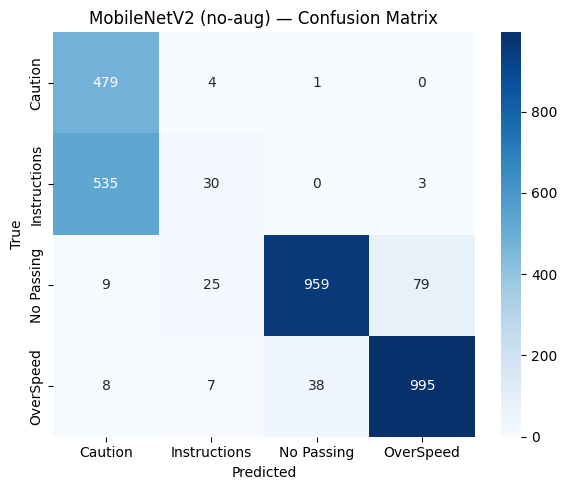

In [61]:
# Evaluate MobileNet (no-aug version, best of the three)
val_gen_mn_eval = ImageDataGenerator(
    preprocessing_function=mobilenet_preprocess,
    validation_split=0.2,
).flow_from_directory(
    TRAIN_DIR,
    target_size=(96, 96),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42,
)

print("Evaluating MobileNetV2 (no-aug)...")
loss_mn, acc_mn = mobilenet_model_noaug.evaluate(val_gen_mn_eval, verbose=1)
print(f"\nMobileNetV2 — Val accuracy: {acc_mn:.4f}, Val loss: {loss_mn:.4f}")

# Manual loop for confusion matrix
val_gen_mn_eval.reset()
y_true_mn, y_pred_mn = [], []
for i in range(len(val_gen_mn_eval)):
    x, y = val_gen_mn_eval[i]
    p = mobilenet_model_noaug.predict(x, verbose=0)
    y_true_mn.extend(np.argmax(y, axis=1))
    y_pred_mn.extend(np.argmax(p, axis=1))

print("\n=== MobileNetV2 — Per-class metrics ===")
print(classification_report(y_true_mn, y_pred_mn, target_names=class_names, zero_division=0))

# Confusion matrix
cm_mn = confusion_matrix(y_true_mn, y_pred_mn)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_mn, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('MobileNetV2 (no-aug) — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

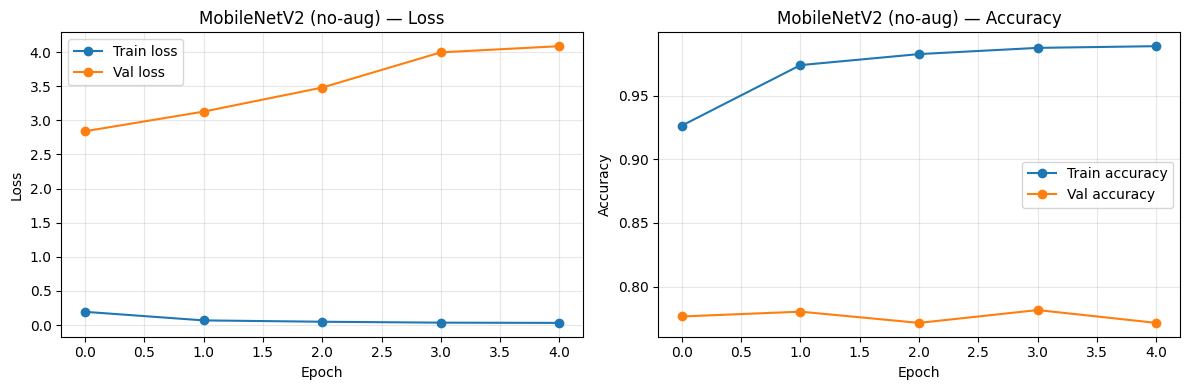

In [62]:
# Plot MobileNet curves
history_mn = mobilenet_history_noaug.history

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_mn['loss'], label='Train loss', marker='o')
axes[0].plot(history_mn['val_loss'], label='Val loss', marker='o')
axes[0].set_title('MobileNetV2 (no-aug) — Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_mn['accuracy'], label='Train accuracy', marker='o')
axes[1].plot(history_mn['val_accuracy'], label='Val accuracy', marker='o')
axes[1].set_title('MobileNetV2 (no-aug) — Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## Master Comparison — All Models

Side-by-side comparison of all eight experimental configurations. This is the central figure summarising the §2.5.4 comparative analysis.

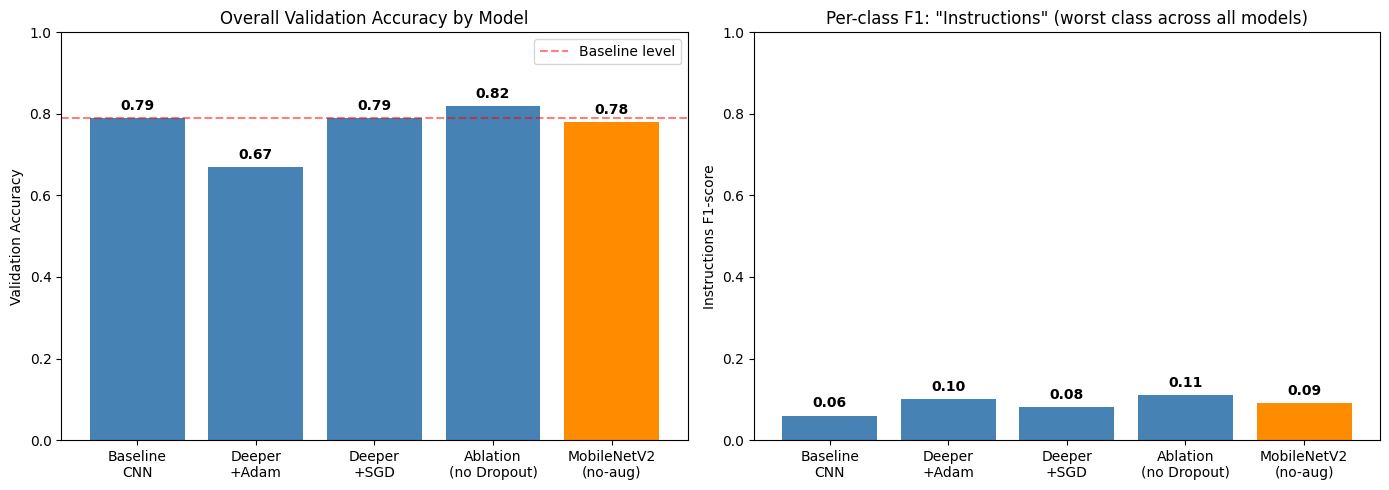

In [63]:
# Master comparison plot — all models side-by-side
import matplotlib.pyplot as plt

models = ['Baseline\nCNN', 'Deeper\n+Adam', 'Deeper\n+SGD',
          'Ablation\n(no Dropout)', 'MobileNetV2\n(no-aug)']
val_acc = [0.79, 0.67, 0.79, 0.82, 0.78]
inst_f1 = [0.06, 0.10, 0.08, 0.11, 0.09]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: overall val accuracy
bars1 = axes[0].bar(models, val_acc, color=['steelblue']*4 + ['darkorange'])
axes[0].set_ylabel('Validation Accuracy')
axes[0].set_title('Overall Validation Accuracy by Model')
axes[0].set_ylim(0, 1.0)
axes[0].axhline(y=0.79, color='red', linestyle='--', alpha=0.5, label='Baseline level')
axes[0].legend()
for i, v in enumerate(val_acc):
    axes[0].text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')

# Right: Instructions class F1 (the persistent failure)
bars2 = axes[1].bar(models, inst_f1, color=['steelblue']*4 + ['darkorange'])
axes[1].set_ylabel('Instructions F1-score')
axes[1].set_title('Per-class F1: "Instructions" (worst class across all models)')
axes[1].set_ylim(0, 1.0)
for i, v in enumerate(inst_f1):
    axes[1].text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()